In [1]:
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings("ignore")
# Load dataset
iris_raw = load_iris()
X_iris = iris_raw.data
y_iris = iris_raw.target

# Standardize features
scaler_iris = StandardScaler()
X_iris_scaled = scaler_iris.fit_transform(X_iris)

# Stratified train-test split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X_iris_scaled, y_iris, test_size=0.20, stratify=y_iris, random_state=42
)

print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)


Training set shape: (120, 4)
Test set shape: (30, 4)


In [2]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Initialize multinomial Logistic Regression classifier
lr_model = LogisticRegression(multi_class='multinomial', solver='lbfgs', random_state=42)
lr_model.fit(X_train, y_train)

# Predict on test data
lr_preds = lr_model.predict(X_test)
lr_accuracy = accuracy_score(y_test, lr_preds)

print(f"Logistic Regression Test Accuracy: {lr_accuracy * 100:.2f}%")


Logistic Regression Test Accuracy: 93.33%


In [3]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

# Initialize LDA classifier
lda_model = LinearDiscriminantAnalysis()
lda_model.fit(X_train, y_train)

# Predict on test data
lda_preds = lda_model.predict(X_test)
lda_accuracy = accuracy_score(y_test, lda_preds)

print(f"LDA Test Accuracy: {lda_accuracy * 100:.2f}%")


LDA Test Accuracy: 100.00%


In [5]:
# Import k-NN classifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Create the k-NN model
knn = KNeighborsClassifier()

# Train the model
knn.fit(X_train, y_train)

# Make predictions
y_pred_knn = knn.predict(X_test)

# Evaluate the model
knn_accuracy = accuracy_score(y_test, y_pred_knn)

print("k-NN Classification Accuracy:", knn_accuracy)


k-NN Classification Accuracy: 0.9333333333333333


In [6]:
# Assemble performance metrics
comparison_df = pd.DataFrame({
    'Supervised Classifier': [
        'Logistic Regression',
        'Linear Discriminant Analysis (LDA)',
        'k-Nearest Neighbors (k-NN)'
    ],
    'Test Accuracy (%)': [
        lr_accuracy * 100,
        lda_accuracy * 100,
        knn_accuracy * 100
    ]
})

print("--- Performance Comparison on Iris Dataset ---")
print(comparison_df.to_string(index=False))

--- Performance Comparison on Iris Dataset ---
             Supervised Classifier  Test Accuracy (%)
               Logistic Regression          93.333333
Linear Discriminant Analysis (LDA)         100.000000
        k-Nearest Neighbors (k-NN)          93.333333


In [7]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Load Sonar dataset
sonar_url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/sonar.csv"
sonar_features = [f"F_{i}" for i in range(1, 61)]
sonar_columns = sonar_features + ['Class']
sonar_df = pd.read_csv(sonar_url, header=None, names=sonar_columns)

# Encode class: M -> 1, R -> 0
sonar_df['Class_numeric'] = sonar_df['Class'].map({'M': 1, 'R': 0})

X_sonar = sonar_df[sonar_features]
y_sonar = sonar_df['Class_numeric']

# Scale features
scaler_sonar = StandardScaler()
X_sonar_scaled = scaler_sonar.fit_transform(X_sonar)

# Split into train/test sets
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_sonar_scaled, y_sonar, test_size=0.30, stratify=y_sonar, random_state=42
)

print("Sonar Training Set Shape:", X_train_s.shape)
print("Sonar Test Set Shape:", X_test_s.shape)


Sonar Training Set Shape: (145, 60)
Sonar Test Set Shape: (63, 60)


In [8]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score

# Initialize and train Gaussian Naïve Bayes model
nb_model = GaussianNB()
nb_model.fit(X_train_s, y_train_s)

# Predict and evaluate accuracy
nb_preds = nb_model.predict(X_test_s)
nb_accuracy = accuracy_score(y_test_s, nb_preds)

print(f"Gaussian Naïve Bayes Test Accuracy: {nb_accuracy * 100:.2f}%")


Gaussian Naïve Bayes Test Accuracy: 76.19%


In [9]:
from sklearn.svm import SVC

# Initialize and train Support Vector Classifier with Linear Kernel
svm_linear = SVC(kernel='linear', probability=True, random_state=42)
svm_linear.fit(X_train_s, y_train_s)

# Predict and evaluate accuracy
linear_preds = svm_linear.predict(X_test_s)
linear_accuracy = accuracy_score(y_test_s, linear_preds)

print(f"Linear Kernel SVM Test Accuracy: {linear_accuracy * 100:.2f}%")


Linear Kernel SVM Test Accuracy: 79.37%


In [10]:
# Assemble performance metrics
sonar_comparison = pd.DataFrame({
    'Classifier': ['Gaussian Naïve Bayes (Probabilistic)', 'Linear Kernel SVM (Maximum-Margin)'],
    'Test Accuracy (%)': [nb_accuracy * 100, linear_accuracy * 100]
})

print("--- Performance Comparison on High-Dimensional Sonar Dataset ---")
print(sonar_comparison.to_string(index=False))


--- Performance Comparison on High-Dimensional Sonar Dataset ---
                          Classifier  Test Accuracy (%)
Gaussian Naïve Bayes (Probabilistic)          76.190476
  Linear Kernel SVM (Maximum-Margin)          79.365079


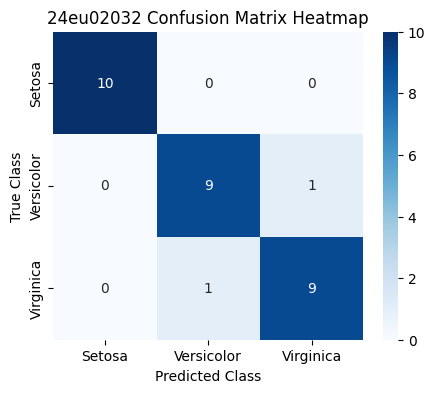

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Compute confusion matrix on Logistic Regression predictions
cm = confusion_matrix(y_test, lr_preds)

# Plot confusion matrix using a Seaborn heatmap
plt.figure(figsize=(5, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Setosa', 'Versicolor', 'Virginica'],
    yticklabels=['Setosa', 'Versicolor', 'Virginica']
)

plt.title("24eu02032 Confusion Matrix Heatmap")
plt.ylabel("True Class")
plt.xlabel("Predicted Class")
plt.show()

In [13]:
from sklearn.metrics import classification_report

# Generate classification report for Logistic Regression
report_output = classification_report(
    y_test,
    lr_preds,
    target_names=['Setosa', 'Versicolor', 'Virginica']
)

print("--- Logistic Regression Classification Report ---")
print(report_output)

--- Logistic Regression Classification Report ---
              precision    recall  f1-score   support

      Setosa       1.00      1.00      1.00        10
  Versicolor       0.90      0.90      0.90        10
   Virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



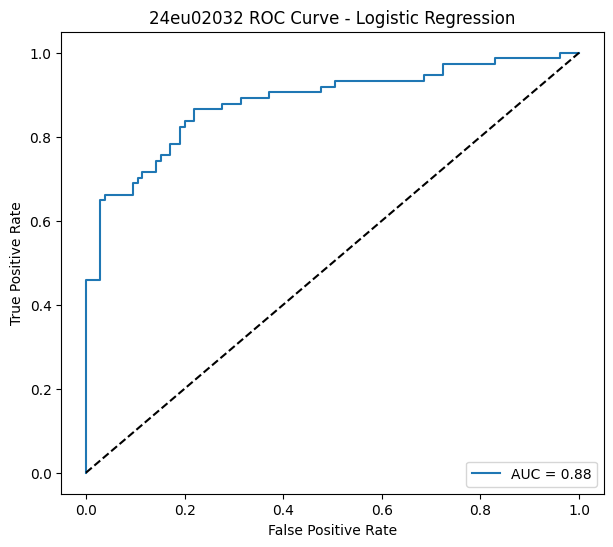

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, auc

# Load Titanic dataset
df = sns.load_dataset('titanic')

# Select required columns
df = df[['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked']]

# Fill missing values
df['age'] = df['age'].fillna(df['age'].median())
df['embarked'] = df['embarked'].fillna(df['embarked'].mode()[0])

# Encode categorical columns
le = LabelEncoder()
df['sex'] = le.fit_transform(df['sex'])
df['embarked'] = le.fit_transform(df['embarked'])

# Features and target
X = df.drop('survived', axis=1)
y = df['survived']

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train Logistic Regression
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)

# Predict probabilities
y_score = lr_model.predict_proba(X_test)

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_score[:, 1])
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7,6))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("24eu02032 ROC Curve - Logistic Regression")
plt.legend(loc="lower right")
plt.show()

In [17]:
# Import libraries
import seaborn as sns
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Load Titanic dataset
df = sns.load_dataset('titanic')

# Display first 5 rows
print("First 5 Rows:")
print(df.head())

# Select important columns
df = df[['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked']]

# Handle missing values
df['age'] = df['age'].fillna(df['age'].median())
df['embarked'] = df['embarked'].fillna(df['embarked'].mode()[0])

# Encode categorical columns
le = LabelEncoder()
df['sex'] = le.fit_transform(df['sex'])
df['embarked'] = le.fit_transform(df['embarked'])

# Features and Target
X = df.drop('survived', axis=1)
y = df['survived']

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train Logistic Regression model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Performance Evaluation
print("\nAccuracy:")
print(accuracy_score(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

First 5 Rows:
   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  

Accuracy:
0.8100558659217877

Confusion Matrix:
[[90 15]
 [19 55]]

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.86      0.84       105
    